# 随机抽取并核验 SE3TD 2D PyG Data

本 notebook 专门核验 `PhiSSeparator_SE3TD_2D.py` 生成的数据。它随机抽取 `.pt` 文件，展示完整分子与全部碎片的结构网格，并整理节点、共价边、活性和对象属性表。

这里只检查 2D 数据契约，不读取或核验三维坐标、三维描述符、全局节点或端口信息。活性字段必须为 `y`，且数值位于 `[0, 3]`。

> 安全提示：`torch.load` 会反序列化 Python 对象，只应加载本项目自行生成且来源可信的 `.pt` 文件。全量清理开关默认关闭。

In [1]:
from pathlib import Path
import gc
import json
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from rdkit import Chem
from rdkit.Chem import Draw
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 200)

# ------------------------------
# 用户配置
# ------------------------------
N_SAMPLES = 1
RANDOM_SEED = 42
ROUND_DIGITS = 6
MOLS_PER_ROW = 4
SUB_IMAGE_SIZE = (320, 240)
EXPORT_CSV = False

FEATURE_COLUMNS = [
    "avg_ecc", "ecc_range", "avg_logp", "tpsa", "avg_charge",
    "HBA", "HBD", "Aromatic", "Hydrophobe", "PosIonizable", "NegIonizable",
]
COUNT_FEATURES = {
    "HBA", "HBD", "Aromatic", "Hydrophobe", "PosIonizable", "NegIonizable"
}
ACTIVITY_FIELD = "y"
DEFAULT_ACTIVITY_RANGE = (0.0, 3.0)


def find_project_root(start: Path) -> Path:
    """允许从项目根目录、ChemCut 目录或其子目录启动 notebook。"""
    start = start.resolve()
    for candidate in (start, *start.parents):
        marker = candidate / "ChemCut" / "PhiSSeparator_SE3TD_2D.py"
        if marker.is_file():
            return candidate
    raise FileNotFoundError("无法定位 PhiStone_2.0 项目根目录，请手动设置 PROJECT_ROOT")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_ROOT = (
    PROJECT_ROOT / "Datas" / "Processed_datas" / "SE3TD_2D_128_Pygdata"
)
DATA_DIR = OUTPUT_ROOT / "pyg_pending"
SUMMARY_PATH = OUTPUT_ROOT / "processing_summary.json"
SHARED_DATA_DIR = (
    PROJECT_ROOT / "Datas" / "Processed_datas"
    / "SE3TD_128_Shared_data"
)
STATS_PATH = SHARED_DATA_DIR / "normalization_stats.json"
EXPORT_DIR = PROJECT_ROOT / "ChemCut" / "pyg_sample_review_2D"

print(f"项目根目录: {PROJECT_ROOT}")
print(f"2D PyG 数据目录: {DATA_DIR}")
print(f"归一化统计: {STATS_PATH}")
print(f"处理汇总: {SUMMARY_PATH}")

项目根目录: /home/node233/miniconda3/envs/PhiStone/project/PhiStone_2.0
2D PyG 数据目录: /home/node233/miniconda3/envs/PhiStone/project/PhiStone_2.0/Datas/Processed_datas/SE3TD_2D_128_Pygdata/pyg_pending
归一化统计: /home/node233/miniconda3/envs/PhiStone/project/PhiStone_2.0/Datas/Processed_datas/SE3TD_128_Shared_data/normalization_stats.json
处理汇总: /home/node233/miniconda3/envs/PhiStone/project/PhiStone_2.0/Datas/Processed_datas/SE3TD_2D_128_Pygdata/processing_summary.json


In [2]:
def load_normalization_params(stats_path: Path) -> dict:
    if not stats_path.is_file():
        raise FileNotFoundError(f"未找到 3D 归一化统计文件: {stats_path}")
    with stats_path.open("r", encoding="utf-8") as file:
        raw_stats = json.load(file)

    missing = set(FEATURE_COLUMNS) - set(raw_stats)
    if missing:
        raise ValueError(f"归一化统计缺少 2D 特征: {sorted(missing)}")

    params = {}
    for name in FEATURE_COLUMNS:
        stats = raw_stats[name]
        if not isinstance(stats, dict) or not {"count", "mean", "M2"} <= set(stats):
            raise ValueError(f"特征 {name} 的统计格式不完整")
        count = float(stats["count"])
        mean = float(stats["mean"])
        m2 = float(stats["M2"])
        if count <= 0 or not np.isfinite([count, mean, m2]).all() or m2 < 0:
            raise ValueError(f"特征 {name} 的统计值非法: {stats}")
        std = float(np.sqrt(m2 / count)) if count >= 2 else 0.0
        params[name] = {"mean": mean, "std": std}
    return params


def load_activity_contract(summary_path: Path) -> tuple[str, tuple[float, float]]:
    activity_field = ACTIVITY_FIELD
    activity_range = DEFAULT_ACTIVITY_RANGE
    if summary_path.is_file():
        with summary_path.open("r", encoding="utf-8") as file:
            summary = json.load(file)
        configured_field = summary.get("activity_field", ACTIVITY_FIELD)
        if configured_field != ACTIVITY_FIELD:
            raise ValueError(
                f"处理汇总中的活性字段应为 {ACTIVITY_FIELD!r}，实际为 {configured_field!r}"
            )
        configured_range = summary.get("activity_range", DEFAULT_ACTIVITY_RANGE)
        if not isinstance(configured_range, (list, tuple)) or len(configured_range) != 2:
            raise ValueError(f"处理汇总中的 activity_range 非法: {configured_range!r}")
        lower = float(configured_range[0])
        upper = float(configured_range[1])
        if not np.isfinite([lower, upper]).all() or (lower, upper) != DEFAULT_ACTIVITY_RANGE:
            raise ValueError(
                f"处理汇总中的活性范围应为 {DEFAULT_ACTIVITY_RANGE}，实际为 {(lower, upper)}"
            )
        activity_range = (lower, upper)
    return activity_field, activity_range


def discover_and_sample(data_dir: Path, sample_count: int, seed: int) -> list[Path]:
    if sample_count <= 0:
        raise ValueError("N_SAMPLES 必须为正整数")
    if not data_dir.is_dir():
        raise FileNotFoundError(f"2D PyG 数据目录不存在: {data_dir}")
    files = sorted(data_dir.rglob("*.pt"), key=lambda path: path.as_posix())
    if not files:
        raise FileNotFoundError(f"目录中没有 .pt 文件: {data_dir}")
    actual_count = min(sample_count, len(files))
    if actual_count < sample_count:
        print(f"仅找到 {len(files)} 个 .pt 文件，将全部载入")
    selected = random.Random(seed).sample(files, actual_count)
    return sorted(selected, key=lambda path: path.as_posix())


def trusted_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def tensor_attr(data, name: str):
    value = getattr(data, name, None)
    return value if isinstance(value, torch.Tensor) else None


def to_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def data_keys(data) -> list[str]:
    keys = data.keys() if callable(getattr(data, "keys", None)) else []
    return list(keys)


def inverse_feature(name: str, normalized_value: float, params: dict) -> tuple[float, bool]:
    value = float(normalized_value)
    stats = params[name]
    safe_std = (
        max(stats["std"], 1.0)
        if name in COUNT_FEATURES
        else (stats["std"] if stats["std"] > 1e-5 else 1.0)
    )
    restored = value * safe_std + stats["mean"]
    return float(restored), bool(np.isclose(abs(value), 6.0))


def count_unique_undirected_edges(edge_index: torch.Tensor) -> int:
    if not isinstance(edge_index, torch.Tensor):
        raise TypeError("edge_index 不是 Tensor")
    if edge_index.ndim != 2 or edge_index.shape[0] != 2:
        raise ValueError(f"edge_index 形状非法: {tuple(edge_index.shape)}")
    if edge_index.shape[1] == 0:
        return 0
    edge_index = edge_index.detach().cpu().to(torch.long)
    low = torch.minimum(edge_index[0], edge_index[1])
    high = torch.maximum(edge_index[0], edge_index[1])
    return int(torch.unique(torch.stack((low, high), dim=1), dim=0).shape[0])

In [3]:
def build_summary_row(data, path: Path, activity_field: str) -> dict:
    x = tensor_attr(data, "x")
    edge_index = tensor_attr(data, "edge_index")
    activity = tensor_attr(data, activity_field)
    return {
        "compound_id": str(getattr(data, "compound_id", path.stem)),
        "file": str(path.relative_to(DATA_DIR)),
        "smiles": str(getattr(data, "smiles", "")),
        "num_nodes": int(x.shape[0]) if x is not None and x.ndim == 2 else None,
        "x_dim": int(x.shape[1]) if x is not None and x.ndim == 2 else None,
        "directed_edges": int(edge_index.shape[1]) if edge_index is not None and edge_index.ndim == 2 else None,
        "undirected_edges": count_unique_undirected_edges(edge_index) if edge_index is not None else None,
        "activity_field": activity_field,
        "activity_value": (
            float(activity.item())
            if activity is not None and activity.numel() == 1 else None
        ),
    }


def build_node_rows(data, path: Path, params: dict) -> list[dict]:
    x = tensor_attr(data, "x")
    if x is None or x.ndim != 2 or x.shape[1] != len(FEATURE_COLUMNS):
        shape = None if x is None else tuple(x.shape)
        raise ValueError(f"{path.name}: x 应为 [N, 11]，实际为 {shape}")

    x_np = to_numpy(x)
    fragments = list(getattr(data, "fragment_smiles", []))
    metal = tensor_attr(data, "metal_mask")
    hac = tensor_attr(data, "hac")
    rings = tensor_attr(data, "ring_count")
    metal_np = to_numpy(metal) if metal is not None else None
    hac_np = to_numpy(hac) if hac is not None else None
    rings_np = to_numpy(rings) if rings is not None else None
    compound_id = str(getattr(data, "compound_id", path.stem))

    rows = []
    for node_index in range(x_np.shape[0]):
        row = {
            "compound_id": compound_id,
            "file": str(path.relative_to(DATA_DIR)),
            "node_index": node_index,
            "fragment_smiles": fragments[node_index] if node_index < len(fragments) else None,
            "is_metal": bool(metal_np[node_index]) if metal_np is not None and node_index < len(metal_np) else None,
            "hac": int(hac_np[node_index]) if hac_np is not None and node_index < len(hac_np) else None,
            "ring_count": int(rings_np[node_index]) if rings_np is not None and node_index < len(rings_np) else None,
        }
        boundary_features = []
        for column_index, name in enumerate(FEATURE_COLUMNS):
            restored, at_boundary = inverse_feature(name, x_np[node_index, column_index], params)
            row[name] = round(restored, ROUND_DIGITS)
            if at_boundary:
                boundary_features.append(name)
        row["inverse_boundary_features"] = ", ".join(boundary_features)
        rows.append(row)
    return rows


def build_edge_rows(data, path: Path) -> list[dict]:
    edge_index = tensor_attr(data, "edge_index")
    if edge_index is None or edge_index.ndim != 2 or edge_index.shape[0] != 2:
        return []
    compound_id = str(getattr(data, "compound_id", path.stem))
    edge_np = to_numpy(edge_index)
    unique_edges = {}
    for edge_number in range(edge_np.shape[1]):
        source = int(edge_np[0, edge_number])
        target = int(edge_np[1, edge_number])
        key = (min(source, target), max(source, target))
        if key not in unique_edges:
            unique_edges[key] = {
                "compound_id": compound_id,
                "file": str(path.relative_to(DATA_DIR)),
                "node_u": key[0],
                "node_v": key[1],
                "directed_occurrences": 0,
            }
        unique_edges[key]["directed_occurrences"] += 1
    return list(unique_edges.values())


def build_activity_rows(
    data,
    path: Path,
    activity_field: str,
    activity_range: tuple[float, float],
) -> list[dict]:
    compound_id = str(getattr(data, "compound_id", path.stem))
    value = tensor_attr(data, activity_field)
    numeric_value = (
        float(value.item())
        if value is not None and value.numel() == 1 else None
    )
    lower, upper = activity_range
    return [{
        "compound_id": compound_id,
        "file": str(path.relative_to(DATA_DIR)),
        "activity": activity_field,
        "value": numeric_value,
        "is_missing": value is None,
        "in_expected_range": (
            numeric_value is not None and lower <= numeric_value <= upper
        ),
        "shape": None if value is None else str(tuple(value.shape)),
        "dtype": None if value is None else str(value.dtype),
    }]


def summarize_attribute(value) -> tuple[str, str, str]:
    if isinstance(value, torch.Tensor):
        flat = value.detach().cpu().reshape(-1)
        return str(tuple(value.shape)), str(value.dtype), repr(flat[:8].tolist())
    if isinstance(value, (list, tuple)):
        return f"len={len(value)}", type(value).__name__, repr(value[:5])
    return "scalar", type(value).__name__, repr(value)


def build_attribute_rows(data, path: Path) -> list[dict]:
    compound_id = str(getattr(data, "compound_id", path.stem))
    rows = []
    for key in sorted(data_keys(data)):
        shape, dtype, preview = summarize_attribute(getattr(data, key))
        rows.append({
            "compound_id": compound_id,
            "file": str(path.relative_to(DATA_DIR)),
            "attribute": key,
            "shape_or_length": shape,
            "dtype": dtype,
            "preview": preview,
        })
    return rows

In [4]:
def build_validation_rows(
    data,
    path: Path,
    activity_field: str,
    activity_range: tuple[float, float],
) -> list[dict]:
    x = tensor_attr(data, "x")
    num_nodes = int(x.shape[0]) if x is not None and x.ndim == 2 else -1
    edge_index = tensor_attr(data, "edge_index")
    fragments = getattr(data, "fragment_smiles", None)
    metal = tensor_attr(data, "metal_mask")
    hac = tensor_attr(data, "hac")
    rings = tensor_attr(data, "ring_count")
    compound_id = str(getattr(data, "compound_id", ""))
    smiles = getattr(data, "smiles", None)

    checks = []
    checks.append(("compound_id", bool(compound_id.strip()), compound_id))
    checks.append(("compound_id_matches_filename", compound_id == path.stem,
                   f"compound_id={compound_id!r}, stem={path.stem!r}"))
    checks.append(("smiles_present", isinstance(smiles, str) and bool(smiles.strip()),
                   None if smiles is None else str(smiles)))

    x_shape_ok = x is not None and x.ndim == 2 and x.shape[1] == len(FEATURE_COLUMNS)
    checks.append(("x_shape_11", x_shape_ok, None if x is None else str(tuple(x.shape))))
    x_finite_ok = x_shape_ok and bool(torch.isfinite(x).all().item())
    checks.append(("x_finite", x_finite_ok, "11 项二维特征应全部为有限值"))

    fragment_ok = (
        isinstance(fragments, (list, tuple)) and len(fragments) == num_nodes
        and all(isinstance(value, str) and bool(value) for value in fragments)
    )
    checks.append(("fragment_smiles_length", fragment_ok,
                   None if fragments is None else f"length={len(fragments)}"))
    checks.append(("metal_mask_shape", metal is not None and metal.dtype == torch.bool
                   and tuple(metal.shape) == (num_nodes,),
                   None if metal is None else f"{tuple(metal.shape)}, {metal.dtype}"))
    checks.append(("hac_shape", hac is not None and hac.dtype == torch.long
                   and tuple(hac.shape) == (num_nodes,),
                   None if hac is None else f"{tuple(hac.shape)}, {hac.dtype}"))
    checks.append(("ring_count_shape", rings is not None and rings.dtype == torch.long
                   and tuple(rings.shape) == (num_nodes,),
                   None if rings is None else f"{tuple(rings.shape)}, {rings.dtype}"))

    edge_shape_ok = edge_index is not None and edge_index.ndim == 2 and edge_index.shape[0] == 2
    checks.append(("edge_index_shape", edge_shape_ok,
                   None if edge_index is None else str(tuple(edge_index.shape))))
    edge_range_ok = edge_shape_ok and (
        edge_index.numel() == 0
        or bool(((edge_index >= 0) & (edge_index < num_nodes)).all().item())
    )
    checks.append(("edge_index_range", edge_range_ok, "允许合法的 [2, 0] 空边"))

    edge_set = set()
    no_self_loops = edge_shape_ok
    no_duplicate_directed_edges = edge_shape_ok
    reciprocal_edges = edge_shape_ok
    if edge_shape_ok:
        edge_list = [tuple(map(int, pair)) for pair in edge_index.t().tolist()]
        edge_set = set(edge_list)
        no_self_loops = all(source != target for source, target in edge_list)
        no_duplicate_directed_edges = len(edge_set) == len(edge_list)
        reciprocal_edges = all((target, source) in edge_set for source, target in edge_set)
    checks.append(("edge_no_self_loops", no_self_loops, None))
    checks.append(("edge_no_directed_duplicates", no_duplicate_directed_edges, None))
    checks.append(("edge_bidirectional", reciprocal_edges,
                   "每条跨 shard 共价边都应存在反向边"))

    activity = getattr(data, activity_field, None)
    activity_tensor_ok = (
        isinstance(activity, torch.Tensor)
        and tuple(activity.shape) == (1,)
        and activity.dtype == torch.float32
        and bool(torch.isfinite(activity).all().item())
    )
    activity_detail = (
        f"{tuple(activity.shape)}, {activity.dtype}"
        if isinstance(activity, torch.Tensor) else repr(activity)
    )
    checks.append(("activity_y_tensor", activity_tensor_ok, activity_detail))

    lower, upper = activity_range
    activity_range_ok = (
        activity_tensor_ok
        and lower <= float(activity.item()) <= upper
    )
    checks.append(("activity_y_range", activity_range_ok,
                   f"expected=[{lower}, {upper}]"))

    legacy_activity_fields = sorted(
        key for key in data_keys(data)
        if key != activity_field and key.startswith("y") and key[1:].isdigit()
    )
    checks.append(("legacy_activity_fields_absent", not legacy_activity_fields,
                   repr(legacy_activity_fields)))

    return [
        {
            "compound_id": compound_id,
            "file": str(path.relative_to(DATA_DIR)),
            "check": name,
            "passed": bool(passed),
            "detail": detail,
        }
        for name, passed, detail in checks
    ]

## 随机抽样、结构网格与核验表

每个样本的第一格是输入表中的完整 SMILES，后续格依节点顺序展示全部碎片。精确 SMILES 同时保存在表格中，避免图例截断造成歧义。无法解析的结构会记录在表格中，不会中断其他样本。

共发现 50080 个 .pt 文件
随机抽取 1 个样本（seed=42）
核验活性字段: y
核验活性范围: [0.0, 3.0]


### 47714

,compound_id,file,structure,smiles,rdkit_parse_ok
0,47714,4/47714.pt,完整分子,Cc1ccc(C)n1-c1ccc(C(=O)NNC(=O)Cc2ccc(Cl)cc2)cc1,True
1,47714,4/47714.pt,碎片 0,C,True
2,47714,4/47714.pt,碎片 1,c1cc[nH]c1,True
3,47714,4/47714.pt,碎片 2,C,True
4,47714,4/47714.pt,碎片 3,c1ccccc1,True
5,47714,4/47714.pt,碎片 4,c1ccccc1,True
6,47714,4/47714.pt,碎片 5,Cl,True
7,47714,4/47714.pt,碎片 6,O=CNNC=O,True
8,47714,4/47714.pt,碎片 7,C,True


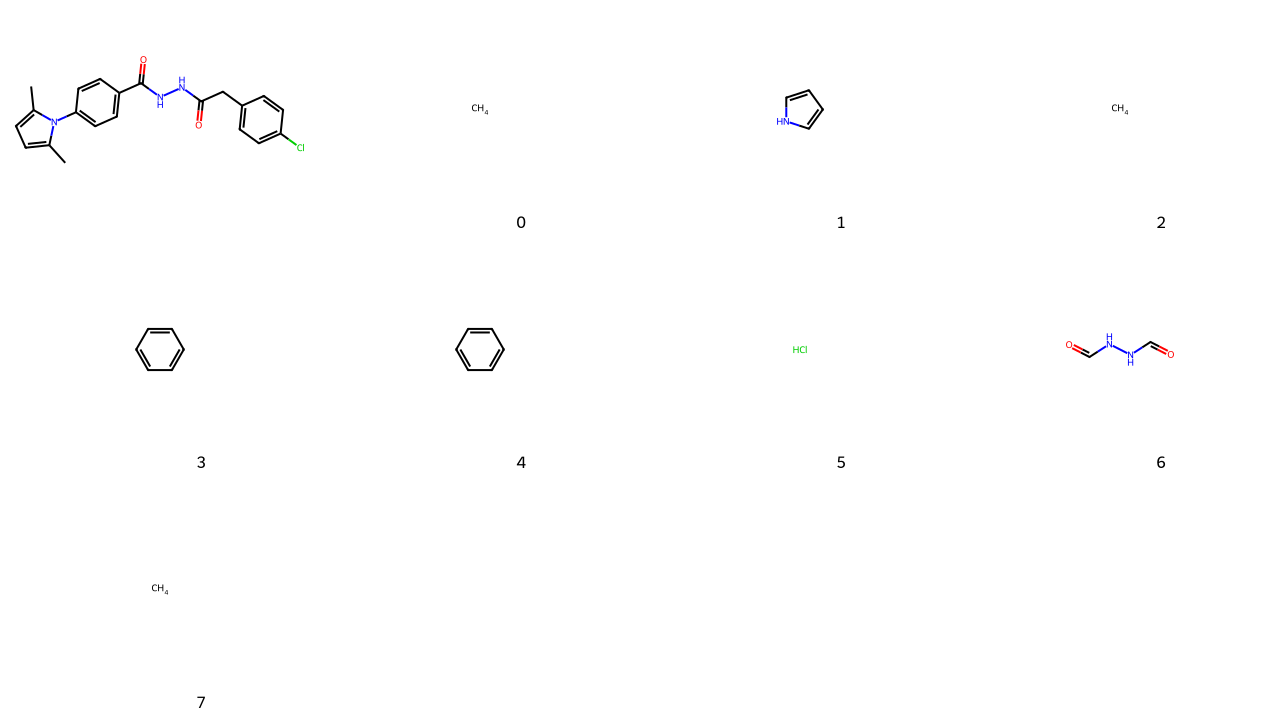

In [5]:
normalization_params = load_normalization_params(STATS_PATH)
activity_field, activity_range = load_activity_contract(SUMMARY_PATH)
selected_files = discover_and_sample(DATA_DIR, N_SAMPLES, RANDOM_SEED)
loaded_samples = [(path, trusted_torch_load(path)) for path in selected_files]

print(f"共发现 {len(list(DATA_DIR.rglob('*.pt')))} 个 .pt 文件")
print(f"随机抽取 {len(selected_files)} 个样本（seed={RANDOM_SEED}）")
print(f"核验活性字段: {activity_field}")
print(f"核验活性范围: [{activity_range[0]}, {activity_range[1]}]")

structure_smiles_rows = []
for path, data in loaded_samples:
    compound_id = str(getattr(data, "compound_id", path.stem))
    entries = [("完整分子", str(getattr(data, "smiles", "")))]
    entries.extend(
        (f"碎片 {index}", str(smiles))
        for index, smiles in enumerate(getattr(data, "fragment_smiles", []))
    )

    molecules = []
    legends = []
    for label, smiles in entries:
        molecule = Chem.MolFromSmiles(smiles) if smiles else None
        parse_ok = molecule is not None
        structure_smiles_rows.append({
            "compound_id": compound_id,
            "file": str(path.relative_to(DATA_DIR)),
            "structure": label,
            "smiles": smiles,
            "rdkit_parse_ok": parse_ok,
        })
        if parse_ok:
            molecules.append(molecule)
            legends.append(label)

    display(Markdown(f"### {compound_id}"))
    display(pd.DataFrame([row for row in structure_smiles_rows if row["file"] == str(path.relative_to(DATA_DIR))]))
    if molecules:
        grid = Draw.MolsToGridImage(
            molecules,
            molsPerRow=MOLS_PER_ROW,
            subImgSize=SUB_IMAGE_SIZE,
            legends=legends,
            useSVG=False,
        )
        display(grid)
    else:
        display(Markdown("**该样本没有可由 RDKit 解析并绘制的 SMILES。**"))

In [6]:
summary_rows = []
node_rows = []
edge_rows = []
activity_rows = []
attribute_rows = []
validation_rows = []

for path, data in loaded_samples:
    summary_rows.append(build_summary_row(data, path, activity_field))
    node_rows.extend(build_node_rows(data, path, normalization_params))
    edge_rows.extend(build_edge_rows(data, path))
    activity_rows.extend(
        build_activity_rows(data, path, activity_field, activity_range)
    )
    attribute_rows.extend(build_attribute_rows(data, path))
    validation_rows.extend(
        build_validation_rows(data, path, activity_field, activity_range)
    )

tables = {
    "sample_summary": pd.DataFrame(summary_rows),
    "structure_smiles": pd.DataFrame(structure_smiles_rows),
    "nodes_inverse_normalized": pd.DataFrame(node_rows),
    "undirected_covalent_edges": pd.DataFrame(edge_rows),
    "activities": pd.DataFrame(activity_rows),
    "attribute_inventory": pd.DataFrame(attribute_rows),
    "validation": pd.DataFrame(validation_rows),
}

for table_name, dataframe in tables.items():
    display(Markdown(f"## {table_name}"))
    if dataframe.empty:
        print("（空表）")
    else:
        display(dataframe)

failed_checks = tables["validation"].loc[~tables["validation"]["passed"]]
if failed_checks.empty:
    print("抽检样本的全部 2D 验证项均通过。")
else:
    print(f"警告：发现 {len(failed_checks)} 个未通过的验证项。")
    display(failed_checks)

## sample_summary

,compound_id,file,smiles,num_nodes,x_dim,directed_edges,undirected_edges,activity_field,activity_value
0,47714,4/47714.pt,Cc1ccc(C)n1-c1ccc(C(=O)NNC(=O)Cc2ccc(Cl)cc2)cc1,8,11,14,7,y,0.8


## structure_smiles

,compound_id,file,structure,smiles,rdkit_parse_ok
0,47714,4/47714.pt,完整分子,Cc1ccc(C)n1-c1ccc(C(=O)NNC(=O)Cc2ccc(Cl)cc2)cc1,True
1,47714,4/47714.pt,碎片 0,C,True
2,47714,4/47714.pt,碎片 1,c1cc[nH]c1,True
3,47714,4/47714.pt,碎片 2,C,True
4,47714,4/47714.pt,碎片 3,c1ccccc1,True
5,47714,4/47714.pt,碎片 4,c1ccccc1,True
6,47714,4/47714.pt,碎片 5,Cl,True
7,47714,4/47714.pt,碎片 6,O=CNNC=O,True
8,47714,4/47714.pt,碎片 7,C,True


## nodes_inverse_normalized

...

## attribute_inventory

,compound_id,file,attribute,shape_or_length,dtype,preview
0,47714,4/47714.pt,compound_id,scalar,str,'47714'
1,47714,4/47714.pt,edge_index,"(2, 14)",torch.int64,"[0, 1, 1, 3, 4, 4, 6, 1]"
2,47714,4/47714.pt,fragment_smiles,len=8,list,"['C', 'c1cc[nH]c1', 'C', 'c1ccccc1', 'c1ccccc1']"
3,47714,4/47714.pt,hac,"(8,)",torch.int64,"[1, 5, 1, 6, 6, 1, 6, 1]"
4,47714,4/47714.pt,metal_mask,"(8,)",torch.bool,"[False, False, False, False, False, False, False, False]"
5,47714,4/47714.pt,ring_count,"(8,)",torch.int64,"[0, 1, 0, 1, 1, 0, 0, 0]"
6,47714,4/47714.pt,smiles,scalar,str,'Cc1ccc(C)n1-c1ccc(C(=O)NNC(=O)Cc2ccc(Cl)cc2)cc1'
7,47714,4/47714.pt,x,"(8, 11)",torch.float32,"[-0.5234478116035461, -1.3494126796722412, 0.9368884563446045, -0.9298316836357117, 0.36139509081840515, -0.42309752106666565, -0.46898484230041504, -0.06181611865758896]"
8,47714,4/47714.pt,y,"(1,)",torch.float32,[0.800000011920929]


## validation

,compound_id,file,check,passed,detail
0,47714,4/47714.pt,compound_id,True,47714
1,47714,4/47714.pt,compound_id_matches_filename,True,"compound_id='47714', stem='47714'"
2,47714,4/47714.pt,smiles_present,True,Cc1ccc(C)n1-c1ccc(C(=O)NNC(=O)Cc2ccc(Cl)cc2)cc1
3,47714,4/47714.pt,x_shape_11,True,"(8, 11)"
4,47714,4/47714.pt,x_finite,True,11 项二维特征应全部为有限值
5,47714,4/47714.pt,fragment_smiles_length,True,length=8
6,47714,4/47714.pt,metal_mask_shape,True,"(8,), torch.bool"
7,47714,4/47714.pt,hac_shape,True,"(8,), torch.int64"
8,47714,4/47714.pt,ring_count_shape,True,"(8,), torch.int64"
9,47714,4/47714.pt,edge_index_shape,True,"(2, 14)"


抽检样本的全部 2D 验证项均通过。


In [7]:
if EXPORT_CSV:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    sample_tag = f"seed_{RANDOM_SEED}_n_{len(selected_files)}"
    for table_name, dataframe in tables.items():
        export_path = EXPORT_DIR / f"{sample_tag}__{table_name}.csv"
        dataframe.to_csv(export_path, index=False, encoding="utf-8-sig")
        print(f"已导出: {export_path}")
else:
    print("EXPORT_CSV=False：本次只在 notebook 中展示，不写出 CSV。")

EXPORT_CSV=False：本次只在 notebook 中展示，不写出 CSV。


# 全量节点/边统计与可控清理

本部分逐个读取数据目录中的全部 `.pt`，统计节点数和去重后的无向共价边数。清理只依据这两个规模指标。

`PERFORM_CLEANING=False` 时完全只读；改为 `True` 后，超出范围的文件会移动到数据目录同级的隔离目录，不会直接删除。范围边界为包含关系。

In [11]:
# ================================================================
# 全量清理超参数：只在本单元格调整范围与开关
# None 表示该方向不设限制；边界值本身会保留
# ================================================================
NODE_COUNT_LIMITS = {
    "min": 1,
    "max": 100,
}

UNDIRECTED_EDGE_COUNT_LIMITS = {
    "min": 0,
    "max": 100,
}

PERFORM_CLEANING = True
QUARANTINE_DIR = DATA_DIR.parent / f"{DATA_DIR.name}_quarantine"


def validate_count_limits(name: str, limits: dict) -> None:
    if set(limits) != {"min", "max"}:
        raise ValueError(f"{name} 必须且只能包含 min、max")
    lower, upper = limits["min"], limits["max"]
    for key, value in (("min", lower), ("max", upper)):
        if value is not None and (not isinstance(value, int) or isinstance(value, bool) or value < 0):
            raise ValueError(f"{name}.{key} 必须是非负整数或 None")
    if lower is not None and upper is not None and lower > upper:
        raise ValueError(f"{name}.min 不能大于 max")


def outside_limits(value: int, limits: dict) -> tuple[bool, bool]:
    too_few = limits["min"] is not None and value < limits["min"]
    too_many = limits["max"] is not None and value > limits["max"]
    return bool(too_few), bool(too_many)


def scan_all_pyg_files(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.rglob("*.pt"), key=lambda path: path.as_posix())
    if not files:
        raise FileNotFoundError(f"目录中没有 .pt 文件: {data_dir}")

    records = []
    for file_number, path in enumerate(tqdm(files, desc="扫描全部 2D PyG Data", unit="file"), start=1):
        record = {
            "file": str(path.relative_to(data_dir)),
            "absolute_path": str(path.resolve()),
            "file_size_bytes": path.stat().st_size,
            "load_ok": False,
            "error": "",
            "num_nodes": np.nan,
            "directed_edges": np.nan,
            "undirected_edges": np.nan,
        }
        data = None
        try:
            data = trusted_torch_load(path)
            x = tensor_attr(data, "x")
            edge_index = tensor_attr(data, "edge_index")
            if x is None or x.ndim != 2:
                raise ValueError("缺少有效 x")
            if edge_index is None or edge_index.ndim != 2 or edge_index.shape[0] != 2:
                raise ValueError("缺少有效 edge_index")
            record.update({
                "load_ok": True,
                "num_nodes": int(x.shape[0]),
                "directed_edges": int(edge_index.shape[1]),
                "undirected_edges": count_unique_undirected_edges(edge_index),
            })
        except Exception as exc:
            record["error"] = f"{type(exc).__name__}: {exc}"
        finally:
            del data
            if file_number % 500 == 0:
                gc.collect()
        records.append(record)

    gc.collect()
    return pd.DataFrame(records)

扫描全部 2D PyG Data:   0%|          | 0/50080 [00:00<?, ?file/s]

,discovered_files,loaded_files,failed_files,total_nodes,total_directed_edges,total_undirected_edges
0,50080,50080,0,414780,753816,376908


,num_nodes,undirected_edges
count,50080.00,50080.00
mean,8.28,7.53
std,4.26,4.47
min,1.00,0.00
25%,6.00,5.00
50%,8.00,7.00
75%,10.00,9.00
max,120.00,119.00


,reason,file_count
0,node_too_few,0
1,node_too_many,4
2,edge_too_few,0
3,edge_too_many,4


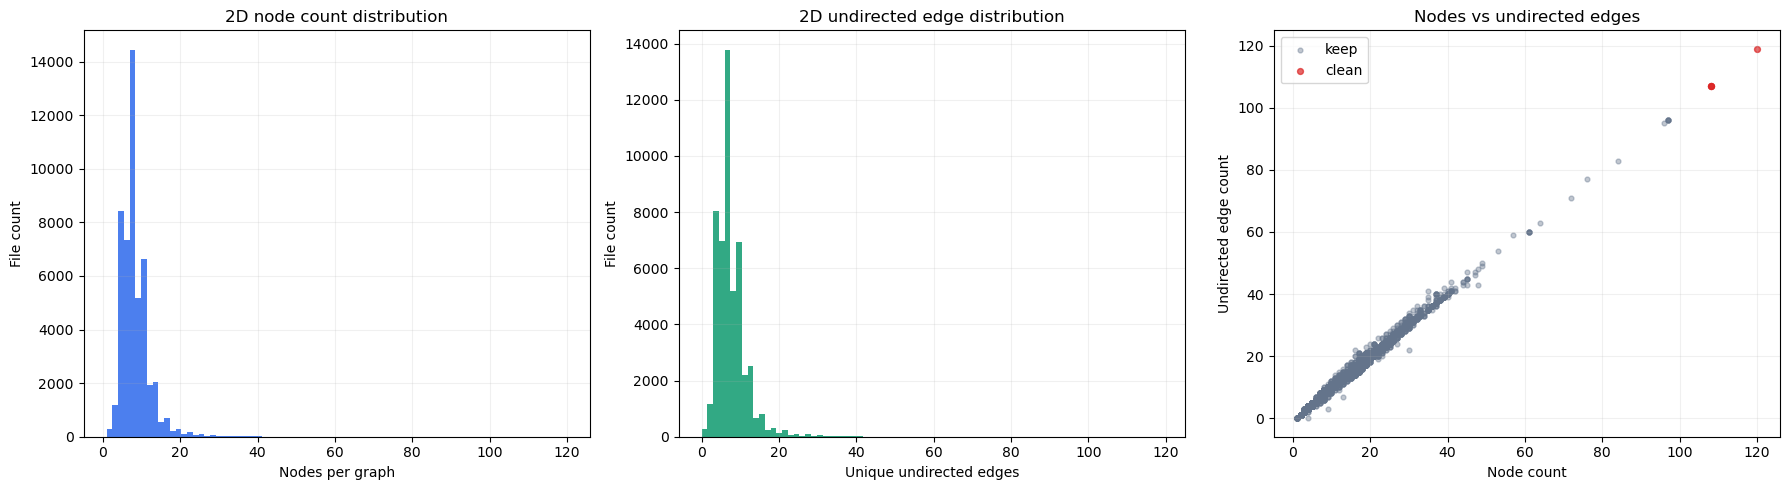

符合保留范围: 50076 个
超出清理范围: 4 个（按文件去重）


In [9]:
validate_count_limits("NODE_COUNT_LIMITS", NODE_COUNT_LIMITS)
validate_count_limits("UNDIRECTED_EDGE_COUNT_LIMITS", UNDIRECTED_EDGE_COUNT_LIMITS)
if not isinstance(PERFORM_CLEANING, bool):
    raise TypeError("PERFORM_CLEANING 必须是 Python 布尔值 True 或 False")

pyg_dataset_statistics = scan_all_pyg_files(DATA_DIR)
valid_graphs = pyg_dataset_statistics.loc[pyg_dataset_statistics["load_ok"]].copy()
failed_graphs = pyg_dataset_statistics.loc[~pyg_dataset_statistics["load_ok"]].copy()
if valid_graphs.empty:
    raise RuntimeError("没有成功加载任何 2D PyG Data")

for column in ("num_nodes", "directed_edges", "undirected_edges"):
    valid_graphs[column] = valid_graphs[column].astype(np.int64)

valid_graphs["node_too_few"] = False
valid_graphs["node_too_many"] = False
valid_graphs["edge_too_few"] = False
valid_graphs["edge_too_many"] = False
for row_index, row in valid_graphs.iterrows():
    node_too_few, node_too_many = outside_limits(int(row["num_nodes"]), NODE_COUNT_LIMITS)
    edge_too_few, edge_too_many = outside_limits(
        int(row["undirected_edges"]), UNDIRECTED_EDGE_COUNT_LIMITS
    )
    valid_graphs.at[row_index, "node_too_few"] = node_too_few
    valid_graphs.at[row_index, "node_too_many"] = node_too_many
    valid_graphs.at[row_index, "edge_too_few"] = edge_too_few
    valid_graphs.at[row_index, "edge_too_many"] = edge_too_many

reason_columns = ["node_too_few", "node_too_many", "edge_too_few", "edge_too_many"]
valid_graphs["should_clean"] = valid_graphs[reason_columns].any(axis=1)
graphs_to_clean = valid_graphs.loc[valid_graphs["should_clean"]].copy()
cleaning_counts = pd.DataFrame({
    "reason": reason_columns,
    "file_count": [int(valid_graphs[column].sum()) for column in reason_columns],
})

dataset_totals = pd.DataFrame([{
    "discovered_files": len(pyg_dataset_statistics),
    "loaded_files": len(valid_graphs),
    "failed_files": len(failed_graphs),
    "total_nodes": int(valid_graphs["num_nodes"].sum()),
    "total_directed_edges": int(valid_graphs["directed_edges"].sum()),
    "total_undirected_edges": int(valid_graphs["undirected_edges"].sum()),
}])
display(dataset_totals)
display(valid_graphs[["num_nodes", "undirected_edges"]].describe().round(2))
display(cleaning_counts)
if not failed_graphs.empty:
    display(Markdown("### 加载失败文件"))
    display(failed_graphs)

histogram_bins = min(80, max(10, int(np.sqrt(len(valid_graphs)))))
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(valid_graphs["num_nodes"], bins=histogram_bins, color="#2563EB", alpha=0.82)
axes[0].set_title("2D node count distribution")
axes[0].set_xlabel("Nodes per graph")
axes[0].set_ylabel("File count")
axes[1].hist(valid_graphs["undirected_edges"], bins=histogram_bins, color="#059669", alpha=0.82)
axes[1].set_title("2D undirected edge distribution")
axes[1].set_xlabel("Unique undirected edges")
axes[1].set_ylabel("File count")
keep_mask = ~valid_graphs["should_clean"]
axes[2].scatter(
    valid_graphs.loc[keep_mask, "num_nodes"],
    valid_graphs.loc[keep_mask, "undirected_edges"],
    s=12, alpha=0.4, color="#64748B", label="keep",
)
if (~keep_mask).any():
    axes[2].scatter(
        valid_graphs.loc[~keep_mask, "num_nodes"],
        valid_graphs.loc[~keep_mask, "undirected_edges"],
        s=18, alpha=0.7, color="#DC2626", label="clean",
    )
axes[2].set_title("Nodes vs undirected edges")
axes[2].set_xlabel("Node count")
axes[2].set_ylabel("Undirected edge count")
axes[2].legend()
for axis in axes:
    axis.grid(alpha=0.18)
figure.tight_layout()
plt.show()

print(f"符合保留范围: {int((~valid_graphs['should_clean']).sum())} 个")
print(f"超出清理范围: {len(graphs_to_clean)} 个（按文件去重）")

In [12]:
cleaned_file_count = 0
cleaning_failure_count = 0

if not PERFORM_CLEANING:
    print("只读模式：PERFORM_CLEANING=False，本次实际移动 0 个文件。")
    print(f"若改为 True，按当前范围将移动 {len(graphs_to_clean)} 个文件。")
else:
    data_root = DATA_DIR.resolve()
    quarantine_root = QUARANTINE_DIR.resolve()
    if quarantine_root == data_root or data_root in quarantine_root.parents:
        raise ValueError("隔离目录不能等于数据目录，也不能位于数据目录内部")
    quarantine_root.mkdir(parents=True, exist_ok=True)

    for row in tqdm(
        graphs_to_clean.itertuples(index=False),
        total=len(graphs_to_clean),
        desc="移动异常规模 2D PyG Data",
        unit="file",
    ):
        source = Path(row.absolute_path).resolve()
        try:
            relative_path = source.relative_to(data_root)
            target = (quarantine_root / relative_path).resolve()
            target.relative_to(quarantine_root)
            if not source.is_file():
                raise FileNotFoundError(f"源文件不存在: {source}")
            if target.exists():
                raise FileExistsError(f"隔离目录中已存在同名文件: {target}")
            target.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(str(source), str(target))
            cleaned_file_count += 1
        except Exception as exc:
            cleaning_failure_count += 1
            tqdm.write(f"[清理失败] {source}: {type(exc).__name__}: {exc}")

    print(f"清理完成：成功移动 {cleaned_file_count} 个文件。")
    print(f"清理失败：{cleaning_failure_count} 个文件。")
    print(f"隔离目录：{quarantine_root}")

移动异常规模 2D PyG Data:   0%|          | 0/4 [00:00<?, ?file/s]

清理完成：成功移动 4 个文件。
清理失败：0 个文件。
隔离目录：/home/node233/miniconda3/envs/PhiStone/project/PhiStone_2.0/Datas/Processed_datas/SE3TD_2D_128_Pygdata/pyg_pending_quarantine
